# Status update 2
## Why classical ML beat deep learning at spotting Fair Value Gaps

### What this maps to (learning outcomes)

- **LO1, Data preparation**: candles, labelling, gold-check, time-ordered split, windowing
- **LO2, Data analysis & model engineering**: a five-model ladder, tuning (G1 to G10), confidence intervals, diagnosis
- **LO3, Professional Standard**: a rule fixed before results, honest limitations, evidence-based advice, bounded scope (zones, not trades), compute spent where it pays
- **LO4, Personal Leadership**: goals set from evidence, a sequenced roadmap, plans adjusted as the data demanded


## 1 · What am I building?

I detect **Fair Value Gaps**, specific zones on a price chart, automatically, and attach a **confidence
score** to each. Not price prediction. Not trading. A detector that reports its confidence in every flag.

First, the only finance needed: a candle.

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "notebook_connected"

BULL, BEAR, NEUTRAL, TEXT = "#26a69a", "#ef5350", "#95a5a6", "#37474f"
SPLIT = {"train": "#1e88e5", "val": "#fb8c00", "test": "#43a047"}
ACCENT, WARN = "#5e35b1", "#c62828"

def synth(opens, highs, lows, closes, names):
    return pd.DataFrame({"open": opens, "high": highs, "low": lows, "close": closes}, index=names)

def candle(sdf):
    return go.Candlestick(x=list(sdf.index), open=sdf["open"], high=sdf["high"],
        low=sdf["low"], close=sdf["close"],
        increasing_line_color=BULL, decreasing_line_color=BEAR, showlegend=False)

def style(fig, title, height=440, ytitle="Price"):
    fig.update_layout(title=title, height=height, template="plotly_white",
        xaxis_rangeslider_visible=False, yaxis_title=ytitle, margin=dict(t=70, b=40))
    return fig

# Five-model results: 5-seed mean macro-F1 with 95% bootstrap CI (block size 60).
# XGBoost is a reference row. It reads 35 hand-engineered features; the four deep
# nets read the raw 60x5 candle window. The XGB gap is partly the easier input,
# not pure architecture, so the fair comparison is deep-net against deep-net.
MODELS = pd.DataFrame([
    ("XGBoost",    "engineered feats", 0.721, 0.671, 0.761, 0.001, None,  None,  None),
    ("CNN-LSTM",   "raw window",       0.639, 0.603, 0.674, 0.013, 0.504, 0.439, 0.88),
    ("LSTM",       "raw window",       0.595, 0.560, 0.628, 0.015, 0.414, 0.402, 0.96),
    ("Transformer","raw window",       0.548, 0.519, 0.572, 0.085, 0.395, 0.282, 0.37),
    ("xLSTM",      "raw window",       0.369, 0.354, 0.384, 0.007, 0.114, 0.056, 0.34),
], columns=["model","family","f1","lo","hi","std","bull","bear","train_f1"])

# Class balance on the labelled data (none / bullish-FVG / bearish-FVG).
CLASS_PCT = {"none": 96.9, "bullish FVG": 1.8, "bearish FVG": 1.3}

# Mean validation macro-F1 vs fraction of training data (3 seeds per point).
# xLSTM was only run at the full-data anchor (see text).
CURVES = {
    "LSTM":        {0.2:0.438, 0.4:0.550, 0.6:0.546, 0.8:0.592, 1.0:0.612},
    "CNN-LSTM":    {0.2:0.486, 0.4:0.527, 0.6:0.575, 0.8:0.562, 1.0:0.602},
    "Transformer": {0.2:0.327, 0.4:0.327, 0.6:0.382, 0.8:0.327, 1.0:0.523},
}
print("Setup ready.")

Setup ready.


In [2]:
# Figure 1: the anatomy of one candle.
demo = synth([100,106],[108,108],[98,100],[105,101],["up hour","down hour"])
fig = go.Figure(candle(demo))
fig.add_annotation(x="up hour", y=108, ax=110, ay=-45, text="<b>wick</b> = high/low reached", showarrow=True, arrowhead=2)
fig.add_annotation(x="up hour", y=102.5, ax=150, ay=0, text="<b>body</b> = open to close", showarrow=True, arrowhead=2)
style(fig, "Figure 1. One candle is one hour. Green closed up, red closed down.", 420)
fig.update_xaxes(type="category"); fig.show()

**What this shows.** A candle is four numbers for one hour. The model sees these numbers, never a
chart image.

## 2 · What is a Fair Value Gap?

A three-candle pattern where price moved so fast it **skipped a band of prices entirely**, a gap that never
traded. Bullish is a fast jump up; bearish is a fast drop. Traders watch these zones; I detect them.

In [3]:
# Figure 2: a bullish Fair Value Gap.
bull = synth([100,101,106],[102,105,110],[99,100,105],[101,104,109],["N-1","N (up)","N+1"])
fig = go.Figure(candle(bull)); y0,y1 = bull["high"].iloc[0], bull["low"].iloc[2]
fig.add_shape(type="rect", x0="N-1", x1="N+1", y0=y0, y1=y1, fillcolor=BULL, opacity=0.22,
              line=dict(color=BULL, width=1.5, dash="dot"))
fig.add_annotation(x="N+1", y=(y0+y1)/2, ax=70, ay=0, text="<b>the gap</b><br>price skipped this zone",
                   showarrow=True, arrowhead=2, font=dict(color="#1b5e20"))
style(fig, "Figure 2. A bullish FVG. The shaded band never traded; price leapt over it.", 460)
fig.update_xaxes(type="category"); fig.show()

In [4]:
# Figure 3: a bearish Fair Value Gap (mirror of Figure 2).
bear = synth([110,109,104],[111,110,106],[108,105,100],[109,106,101],["N-1","N (down)","N+1"])
fig = go.Figure(candle(bear)); y0,y1 = bear["high"].iloc[2], bear["low"].iloc[0]
fig.add_shape(type="rect", x0="N-1", x1="N+1", y0=y0, y1=y1, fillcolor=BEAR, opacity=0.22,
              line=dict(color=BEAR, width=1.5, dash="dot"))
fig.add_annotation(x="N+1", y=(y0+y1)/2, ax=70, ay=0, text="<b>the gap</b><br>price skipped this zone",
                   showarrow=True, arrowhead=2, font=dict(color="#b71c1c"))
style(fig, "Figure 3. A bearish FVG. A fast drop skips the band.", 460)
fig.update_xaxes(type="category"); fig.show()

**What this shows.** Both are purely geometric, defined by three candles. That is why a rule can label
them and a model can learn them.

## 3 · Why a model, not just a rule?

A rule gives yes/no. A model gives a **calibrated probability**, "80% sure", so a user can rank and filter
zones. The rule is the teacher; the model learns to imitate it and to express doubt.

**The data, briefly:** SPY hourly 2016 to 2025 (Alpaca); a 6-criterion rule labels none / bull / bear
(about 97% / 1.8% / 1.3%); a hand-checked gold set confirms the labels (kappa near 1.0, where 1.0 is perfect agreement); a strict
time-ordered split (never shuffled); each example is the last **60 hours by 5 numbers**.

In [5]:
# Figure 4: how rare the gaps are.
labels = list(CLASS_PCT); vals = list(CLASS_PCT.values())
fig = go.Figure(go.Bar(x=labels, y=vals, marker_color=[NEUTRAL, BULL, BEAR],
                       text=[f"{v}%" for v in vals], textposition="outside"))
style(fig, "Figure 4. The classes are extremely lopsided: about 97% of hours are 'no gap'.",
      430, ytitle="% of labelled hours")
fig.update_yaxes(range=[0,105]); fig.show()

**Why this matters.** The classes are extremely lopsided, so plain accuracy is meaningless. The metric
is **macro-F1**, which gives the rare bull and bear gaps equal weight.

## 4 · The question

> **Why did classical ML (XGBoost) detect FVGs *better* than deep learning, and is deep learning the wrong
> tool, or just starved of something?**

The catch: the two families read the **same 60 hours differently**.
- **XGBoost** uses 35 **hand-engineered** summary numbers (human-assisted, easier).
- **Deep nets** use the **raw 60x5 grid** (must learn everything themselves).

So the fair fight is **deep-net against deep-net on raw input**.

In [6]:
# Figure 6: two ways to show a model the same 60 hours.
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "Engineered features (XGBoost)<br><sub>60 hours into 35 hand-made numbers</sub>",
    "Raw window (the deep nets)<br><sub>the full 60x5 grid, learn its own features</sub>"))
feats = ["range", "body %", "volume z", "trend slope", "31 more"]
fig.add_bar(x=feats, y=[0.8,0.5,0.65,0.4,0.3], marker_color=ACCENT, row=1, col=1, showlegend=False)
grid = np.random.RandomState(0).rand(5, 12)
fig.add_heatmap(z=grid, colorscale="Blues", showscale=False, row=1, col=2)
fig.update_yaxes(title_text="value", row=1, col=1)
fig.update_yaxes(title_text="O H L C V", row=1, col=2, showticklabels=False)
fig.update_xaxes(title_text="time", row=1, col=2, showticklabels=False)
fig.update_layout(height=430, template="plotly_white",
    title="Figure 6. The same 60 hours, two representations. This difference is the question.")
fig.show()

## 5 · What I did to find out

1. **Completed the ladder**: LSTM, CNN-LSTM, Transformer, xLSTM (plain to most expressive). *If bigger keeps
   winning, it needs capacity. If bigger stalls, it does not.*
2. **Learning-curve experiment**: retrain on 20% to 100% of the data. Still rising means hungry for data; flat would mean more data will not help.
3. **Fixed the verdict rule before looking**: a 2x2 matrix, so no hindsight.

Every model trained five times with **95% confidence intervals**, so I never mistake noise for a finding.

## 6 · The scoreboard

In [7]:
# Figure 7: the scoreboard, with confidence intervals.
d = MODELS.sort_values("f1")
colors = [NEUTRAL if m=="XGBoost" else (ACCENT if m=="CNN-LSTM" else "#90a4ae") for m in d["model"]]
fig = go.Figure(go.Bar(
    y=d["model"], x=d["f1"], orientation="h", marker_color=colors,
    error_x=dict(type="data", symmetric=False,
                 array=d["hi"]-d["f1"], arrayminus=d["f1"]-d["lo"], color=TEXT, thickness=1.5),
    text=[f"{v:.3f}" for v in d["f1"]], textposition="outside", showlegend=False))
fig.add_vline(x=0.328, line_dash="dot", line_color=WARN,
              annotation_text="always-guess-'none' floor", annotation_position="top")
style(fig, "Figure 7. Five-model scoreboard (5 seeds, 95% CI). Overlapping bars mean a statistical tie.", 460, ytitle="")
fig.update_xaxes(title="macro-F1 (higher is better; equal credit to the rare bull and bear zones)", range=[0,0.85])
fig.show()

**Read it honestly.** CNN-LSTM (0.639) and LSTM (0.595) bars overlap, so they are a **statistical
tie**; CNN-LSTM wins on secondary grounds and I say so. The **two biggest** models sit at the bottom.
XGBoost (0.721) leads, but on the easier engineered input, so not a pure-architecture win.

In [8]:
# Figure 8: where the models actually struggle (per-class F1).
d = MODELS.dropna(subset=["bull"]).iloc[::-1]
fig = go.Figure()
fig.add_bar(name="bullish-FVG F1", y=d["model"], x=d["bull"], orientation="h", marker_color=BULL)
fig.add_bar(name="bearish-FVG F1", y=d["model"], x=d["bear"], orientation="h", marker_color=BEAR)
fig.update_layout(barmode="group", height=430, template="plotly_white",
    title="Figure 8. The rare classes are the hard part. Every model finds the common 'none' well;<br>"
          "<sub>they separate on how well they catch the bull and bear gaps.</sub>",
    legend=dict(orientation="h", y=-0.18))
fig.update_xaxes(title="F1 on the minority class", range=[0,0.7])
fig.show()

**Where they fail.** Everyone finds "none". The models separate on the rare bull and bear gaps, and
that is where the difficulty lives.

## 7 · Every model got a fair hearing

| Model | Score | What it taught me |
|---|---|---|
| **XGBoost** | 0.721* | Classical control; hard to beat on scarce data (*easier input) |
| **CNN-LSTM** | **0.639** | Best deep net; its built-in shape detector fits an FVG |
| **LSTM** | 0.595 | Fits training well, generalises less, so it wants more data |
| **Transformer** | 0.548 | Unstable across seeds (±0.085): some runs reach ~0.59, others collapse |
| **xLSTM** | 0.369 | Newest design, yet cannot even fit train; an informative loss |

xLSTM is the most useful failure: a more complex model scoring *worse* is direct proof that complexity is
not what the task lacks.

## 8 · What I observed, and the verdict

In [9]:
# Figure 9: can the model even memorise the training data?
d = MODELS.dropna(subset=["train_f1"]).sort_values("train_f1")
fig = go.Figure()
fig.add_bar(name="train F1 (fit on seen data)", y=d["model"], x=d["train_f1"], orientation="h", marker_color="#b0bec5")
fig.add_bar(name="test F1 (generalise to unseen)", y=d["model"], x=d["f1"], orientation="h", marker_color=ACCENT)
fig.update_layout(barmode="group", height=430, template="plotly_white",
    title="Figure 9. Two failure modes. xLSTM and Transformer cannot fit train (left bars low);<br>"
          "<sub>LSTM and CNN-LSTM fit train well but the gap to test stays wide.</sub>",
    legend=dict(orientation="h", y=-0.18))
fig.update_xaxes(title="macro-F1", range=[0,1.0])
fig.show()

In [10]:
# Figure 10: does more data still help? (validation F1 vs training-set size)
fig = go.Figure()
cmap = {"LSTM":"#1e88e5", "CNN-LSTM":ACCENT, "Transformer":"#fb8c00"}
for m, pts in CURVES.items():
    xs = sorted(pts); ys = [pts[x] for x in xs]
    fig.add_scatter(x=[int(x*100) for x in xs], y=ys, mode="lines+markers", name=m, line=dict(color=cmap[m], width=2))
fig.add_hline(y=0.328, line_dash="dot", line_color=WARN, annotation_text="majority-only floor")
style(fig, "Figure 10. The recurrent nets keep improving with more data (no flattening yet).<br>"
           "<sub>The curves are noisy over 3 seeds, so the honest read is 'no plateau', not a precise slope. "
           "Transformer sits near the floor until it finally has all the data.</sub>", 480, ytitle="validation macro-F1")
fig.update_xaxes(title="% of training data used")
fig.show()

In [11]:
# Figure 11: the decision rule, fixed before looking at results.
fig = go.Figure()
# x: 0 = train-F1 LOW (cannot fit), 1 = train-F1 HIGH (fits)
# y: 0 = curve FLAT, 1 = curve still RISING
cells = [
    (1,1,"data + regularisation-bound","more data","#c8e6c9","CNN-LSTM, LSTM"),  # fits + rising
    (0,1,"data + capacity-bound","more data, then size","#fff9c4",""),            # rising but cannot fit
    (1,0,"over-fit / reg-bound","regularise or augment","#ffe0b2",""),            # fits but flat
    (0,0,"capacity / cannot fit","bigger or fix training","#ffcdd2","Transformer, xLSTM"),  # cannot fit + flat
]
for x,y,label,lever,color,who in cells:
    fig.add_shape(type="rect", x0=x, x1=x+1, y0=y, y1=y+1, fillcolor=color, line=dict(color="white", width=3))
    fig.add_annotation(x=x+0.5, y=y+0.62, text=f"<b>{label}</b>", showarrow=False, font=dict(size=12))
    fig.add_annotation(x=x+0.5, y=y+0.40, text=f"lever: {lever}", showarrow=False, font=dict(size=10, color=TEXT))
    if who:
        fig.add_annotation(x=x+0.5, y=y+0.18, text=who, showarrow=False, font=dict(size=11, color=ACCENT))
fig.update_xaxes(range=[0,2], tickvals=[0.5,1.5], ticktext=["train F1 LOW<br>(cannot fit)","train F1 HIGH<br>(fits)"], title="")
fig.update_yaxes(range=[0,2], tickvals=[0.5,1.5], ticktext=["curve FLAT","curve still RISING"], title="")
fig.update_layout(height=470, template="plotly_white",
    title="Figure 11. The decision matrix, committed before the experiments. Each model lands in one box.")
fig.show()

**Two signals agree:** the workable models are still improving with more data, and the biggest models
did worse. Both point one way.

> ### The problem is **data-bound**, not capacity-bound.
> The limit is how much signal exists in one instrument's rare events, not the size of the network.

## 8b · The product surface: how I read and run the model

The assignment wants a usable detector, not just scores. Two tools already exist (figures are illustrative).
- **Inspection tool**: the model's per-class probability for every hour, against the labels, so I can see
  where it is confident, where it hesitates, and where it misses.
- **Paper-trading harness**: replays live hourly data and logs the flagged gaps with confidence, dry-run,
  no real orders.

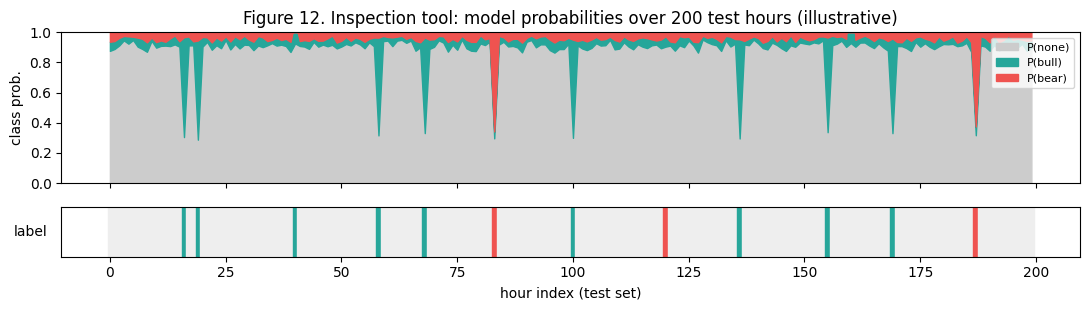

In [12]:
# Figure 12 (illustrative): the inspection tool, a probability strip against the labels.
import matplotlib.pyplot as plt
rng = np.random.default_rng(7); T = 200
p_bull = np.clip(0.02 + 0.6*(rng.random(T)>0.96) + 0.05*rng.random(T), 0, 1)
p_bear = np.clip(0.02 + 0.6*(rng.random(T)>0.97) + 0.05*rng.random(T), 0, 1)
p_none = np.clip(1 - p_bull - p_bear, 0, 1)
gold = np.zeros(T, int); gold[p_bull>0.4]=1; gold[p_bear>0.4]=2
gold[40]=1; p_bull[40]=0.15; gold[120]=2; p_bear[120]=0.18; p_bull[160]=0.7
fig, ax = plt.subplots(2,1, figsize=(11,3.2), sharex=True, gridspec_kw={"height_ratios":[3,1]})
ax[0].fill_between(range(T), 0, p_none, color="#cccccc", label="P(none)")
ax[0].fill_between(range(T), p_none, p_none+p_bull, color="#26a69a", label="P(bull)")
ax[0].fill_between(range(T), p_none+p_bull, 1, color="#ef5350", label="P(bear)")
ax[0].set_ylim(0,1); ax[0].set_ylabel("class prob."); ax[0].legend(loc="upper right", fontsize=8)
ax[0].set_title("Figure 12. Inspection tool: model probabilities over 200 test hours (illustrative)")
cmap = {0:"#eeeeee",1:"#26a69a",2:"#ef5350"}
for t,gv in enumerate(gold): ax[1].axvspan(t-0.5, t+0.5, color=cmap[int(gv)])
ax[1].set_yticks([]); ax[1].set_xlabel("hour index (test set)")
ax[1].set_ylabel("label", rotation=0, labelpad=22, va="center")
plt.tight_layout(); plt.show()

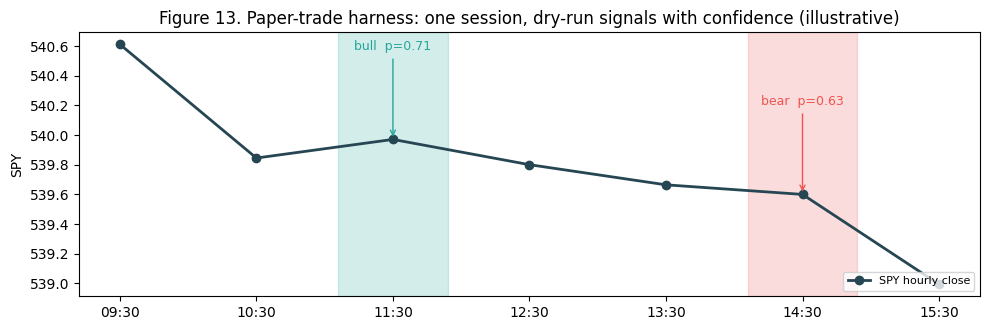

In [13]:
# Figure 13 (illustrative): one paper-trade session, dry-run decisions logged.
import matplotlib.pyplot as plt
rng = np.random.default_rng(3); hours = np.arange(7)
price = 540 + np.cumsum(rng.normal(0, 0.3, len(hours)))
sig_t=[2,5]; sig_kind=["bull","bear"]; sig_conf=[0.71,0.63]
fig, ax = plt.subplots(figsize=(10,3.4))
ax.plot(hours, price, color="#264653", lw=2, marker="o", label="SPY hourly close")
for t,k,cf in zip(sig_t, sig_kind, sig_conf):
    col = "#26a69a" if k=="bull" else "#ef5350"
    ax.axvspan(t-0.4, t+0.4, color=col, alpha=0.2)
    ax.annotate(f"{k}  p={cf:.2f}", xy=(t, price[t]), xytext=(t, price[t]+0.6),
                ha="center", fontsize=9, color=col, arrowprops=dict(arrowstyle="->", color=col))
ax.set_xticks(hours); ax.set_xticklabels(["09:30","10:30","11:30","12:30","13:30","14:30","15:30"])
ax.set_ylabel("SPY"); ax.set_title("Figure 13. Paper-trade harness: one session, dry-run signals with confidence (illustrative)")
ax.legend(loc="lower right", fontsize=8); plt.tight_layout(); plt.show()

## 9 · Progress alongside the headline

- **The five-model ladder is finished** and trained under one set of rules, so the comparison is complete.
- **Scores carry a range, not one number.** Training has randomness, so I run each model five times. CNN-LSTM
  and LSTM overlap once that spread is counted, so I call them a tie instead of declaring a winner.
- **Giving the Transformer a fair second chance.** It did badly partly because it was untuned, so I am
  running a properly-tuned version to answer "maybe a bigger model just needed tuning" with an experiment,
  not an assumption.

## 10 · Next steps, and why I am confident

**Because it is data-bound, the lever is more and richer data, not a bigger model:**
1. **Multi-symbol expansion** (QQQ, IWM, sector ETFs) first, the blocker: multiplies the rare gap examples; targets CNN-LSTM.
2. **Finish the Transformer fairness pass** on current data: close the "bigger model" door with evidence.
3. **Re-judge on the bigger data** the models that can use it (CNN-LSTM, LSTM, Transformer). xLSTM is excluded: it cannot fit the data it already has.
4. **Build the demo**: the confidence-scored detector with chart overlays.

**Why I trust the conclusion:** rule fixed before results; two independent signals agree; every number has a
confidence interval; all counter-evidence is on the record. If multi-symbol data fails to help, the
data-bound story is wrong, and that is the next milestone's falsification test.

## 11 · Reflection

- **Technical**: one score cannot diagnose a model; the same 0.5-ish meant "starved" for one and "cannot
  train" for another. Built-in bias (CNN-LSTM) beat raw capacity on small data.
- **Methodological**: committing to the verdict rule before results turned "which is best?" into a
  falsifiable experiment; the xLSTM failure carried the proof. I leave with a lower score than XGBoost but
  with a clear, evidence-backed reason for what to do next.

## References

López de Prado (2018) *Advances in Financial ML* · Vaswani et al. (2017) *Attention Is All You Need* ·
Beck et al. (2024) *xLSTM* · Efron and Tibshirani (1993) *Introduction to the Bootstrap*.